In [1]:
import cv2
image = cv2.imread('/content/sample_data/meeting1.jpg')

In [2]:
image2 = cv2.imread('/content/sample_data/meeting2.jpg')

Meeting 1


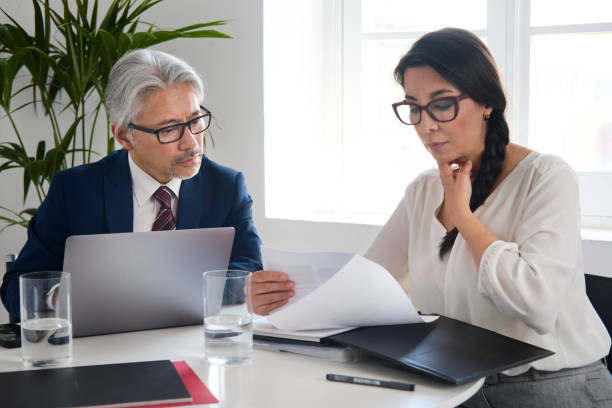

Meeting 2


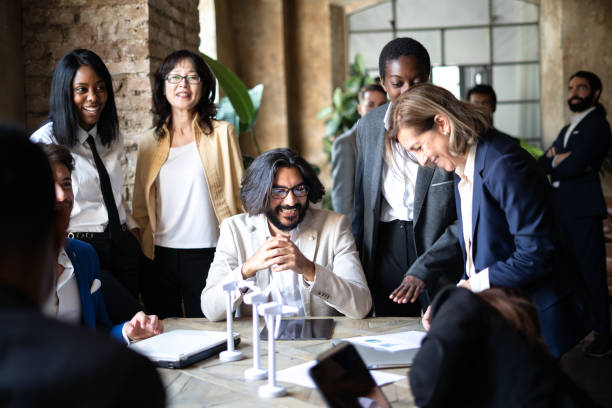

In [3]:
from google.colab.patches import cv2_imshow
print("Meeting 1")
cv2_imshow(image)

print("Meeting 2")
cv2_imshow(image2)

**FACE DETECTION**

In [4]:
image.shape

(408, 612, 3)

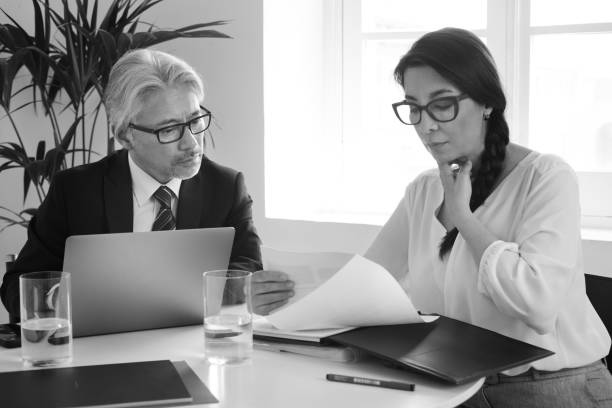

In [5]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2_imshow(image_gray)

In [6]:
!wget -O deploy.prototxt https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt

!wget -O res10_300x300_ssd_iter_140000.caffemodel https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel


--2026-05-31 05:31:41--  https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 28104 (27K) [text/plain]
Saving to: ‘deploy.prototxt’

deploy.prototxt     100%[===================>]  27.45K  --.-KB/s    in 0.002s  

2026-05-31 05:31:41 (17.0 MB/s) - ‘deploy.prototxt’ saved [28104/28104]

--2026-05-31 05:31:41--  https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP r

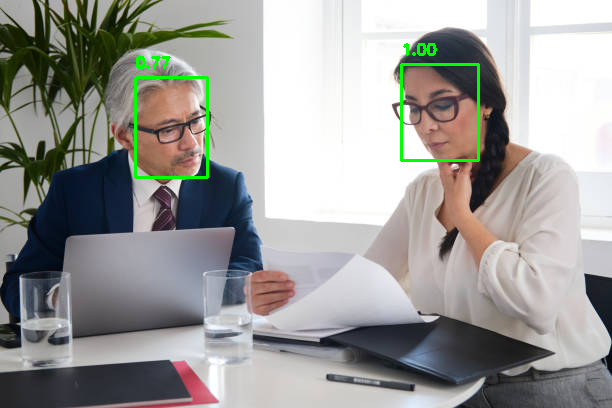

In [7]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load image
image = cv2.imread('/content/sample_data/meeting1.jpg')

(h, w) = image.shape[:2]

# Load DNN model
net = cv2.dnn.readNetFromCaffe(
    "deploy.prototxt",
    "res10_300x300_ssd_iter_140000.caffemodel"
)

# Create blob
blob = cv2.dnn.blobFromImage(
    cv2.resize(image, (300, 300)),
    1.0,
    (300, 300),
    (104.0, 177.0, 123.0)
)

net.setInput(blob)
detections = net.forward()

# Loop through detections
for i in range(detections.shape[2]):

    confidence = detections[0, 0, i, 2]

    if confidence > 0.5:

        box = detections[0, 0, i, 3:7] * np.array(
            [w, h, w, h]
        )

        (startX, startY, endX, endY) = box.astype("int")

        cv2.rectangle(
            image,
            (startX, startY),
            (endX, endY),
            (0, 255, 0),
            2
        )

        cv2.putText(
            image,
            f"{confidence:.2f}",
            (startX, startY - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.5,
            (0, 255, 0),
            2
        )

cv2_imshow(image)

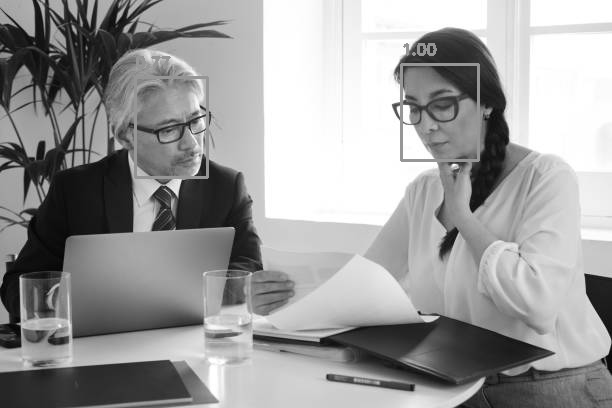

In [8]:
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2_imshow(image_gray)

In [9]:
image_gray.shape

(408, 612)

**HOG-Detecting faces**

In [10]:
import dlib
face_detector_hog = dlib.get_frontal_face_detector()

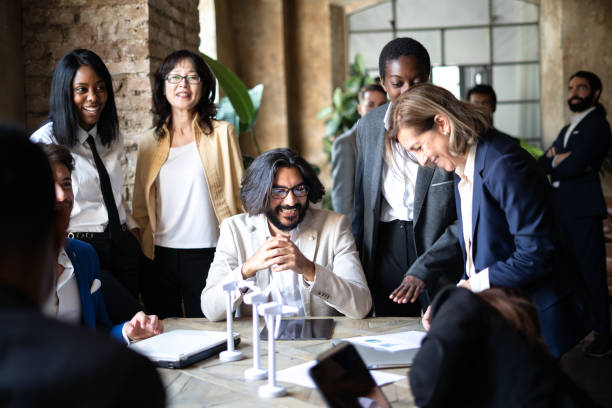

In [11]:
image2 = cv2.imread('/content/sample_data/meeting2.jpg')
cv2_imshow(image2)

In [12]:
face_detector_hog = dlib.get_frontal_face_detector()

In [13]:
detections = face_detector_hog(image2, 1)

In [14]:
detections, len(detections)

(rectangles[[(165, 66) (201, 102)], [(266, 180) (309, 223)], [(69, 79) (112, 122)]],
 3)

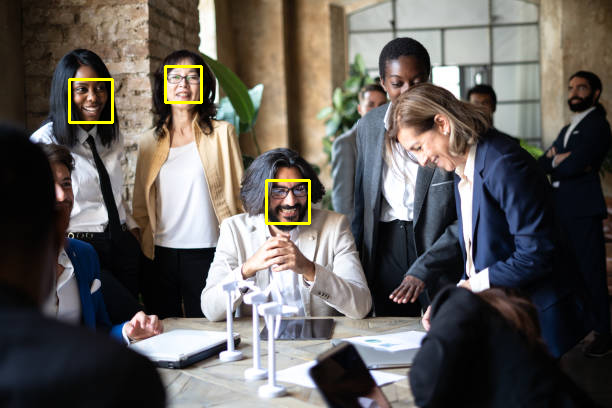

In [15]:
for face in detections:
    l = face.left()
    t = face.top()
    r = face.right()
    b = face.bottom()

    cv2.rectangle(image2, (l, t), (r, b), (0, 255, 255), 2)

cv2_imshow(image2)

CNN-Detecting faces

1.1044926643371582
1.086861252784729
1.0805690288543701
0.5575361251831055


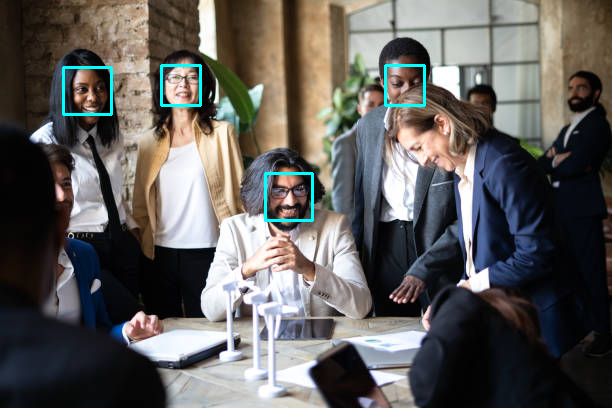

In [17]:
image2 = cv2.imread('/content/sample_data/meeting2.jpg')
cnn_detector = dlib.cnn_face_detection_model_v1('/content/sample_data/mmod_human_face_detector.dat')
detections = cnn_detector(image2, 1)
for face in detections:
  l, t, r, b, c = face.rect.left(), face.rect.top(), face.rect.right(), face.rect.bottom(), face.confidence
  print(c)
  cv2.rectangle(image2, (l, t), (r, b), (255, 255, 0), 2)
cv2_imshow(image2)

In [24]:
!pip install deepface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.7/170.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.4/70.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.6 MB/s eta 0:00:00


Face 1: neutral
Face 2: happy
Face 3: happy
Face 4: happy


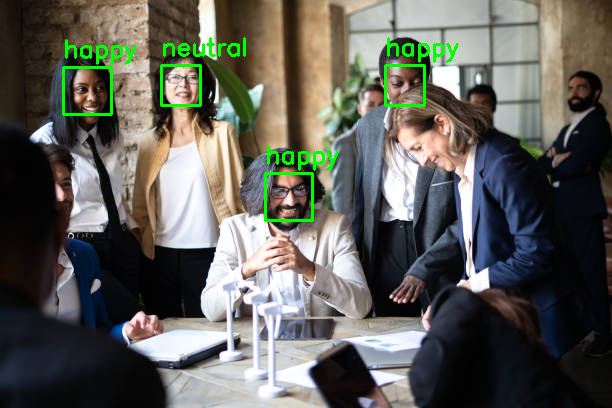

In [26]:
import cv2
import dlib
from deepface import DeepFace
from google.colab.patches import cv2_imshow

image = cv2.imread('/content/sample_data/meeting2.jpg')

cnn_detector = dlib.cnn_face_detection_model_v1(
    '/content/sample_data/mmod_human_face_detector.dat'
)

detections = cnn_detector(image, 1)

for i, face in enumerate(detections):
    l = face.rect.left()
    t = face.rect.top()
    r = face.rect.right()
    b = face.rect.bottom()

    face_crop = image[t:b, l:r]

    result = DeepFace.analyze(
        face_crop,
        actions=['emotion'],
        enforce_detection=False
    )

    emotion = result[0]['dominant_emotion']

    # Draw face rectangle
    cv2.rectangle(image, (l, t), (r, b), (0, 255, 0), 2)

    # Write emotion above the face
    cv2.putText(
        image,
        emotion,
        (l, t - 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 0),
        2
    )

    print(f"Face {i+1}: {emotion}")

cv2_imshow(image)



**FACE RECOGNITION**

In [5]:
import os

from PIL import Image
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import drive

In [1]:
import os
import re
import numpy as np
from PIL import Image

def get_image_data():
    paths = [os.path.join('/content/sample_data/F1', f)
             for f in os.listdir('/content/sample_data/F1')]

    faces = []
    names = []

    for path in paths:
        image = Image.open(path).convert('L')
        image_np = np.array(image, dtype='uint8')

        filename = os.path.basename(path)
        name = re.match(r'[A-Za-z]+', os.path.splitext(filename)[0]).group()

        names.append(name)
        faces.append(image_np)

    return np.array(names), faces

names, faces = get_image_data()






In [2]:
names, faces = get_image_data()

In [8]:
unique_names = list(set(names))

name_to_id = {name: i for i, name in enumerate(unique_names)}

labels = np.array([name_to_id[name] for name in names])

In [9]:
lbph_classifier.train(faces, labels)

In [10]:
names

array(['carlos', 'carlos', 'carlos', 'rivaldo', 'carlos', 'ronaldinho',
       'rivaldo', 'oliver', 'oliver', 'ronaldo', 'oliver', 'ronaldo',
       'ronaldinho', 'oliver', 'ronaldo', 'ronaldinho', 'ronaldinho',
       'ronaldo', 'rivaldo', 'ronaldo', 'oliver', 'carlos', 'rivaldo',
       'ronaldinho', 'rivaldo'], dtype='<U10')

In [11]:
id_to_name = {v: k for k, v in name_to_id.items()}

In [12]:
image = cv2.imread('/content/sample_data/F1/r1.jpg')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)



## **TEST IMAGE:RONALDO**

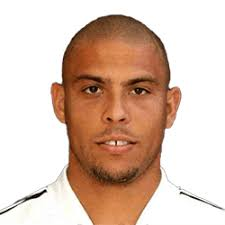

In [17]:
from IPython.display import display, Markdown
from google.colab.patches import cv2_imshow
import cv2

image = cv2.imread('/content/sample_data/F1/r1.jpg')

display(Markdown("## **TEST IMAGE:RONALDO**"))

cv2_imshow(image)

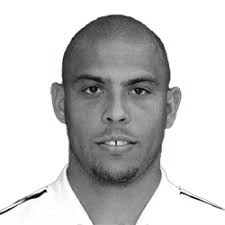

ronaldo


In [20]:

label, confidence = lbph_classifier.predict(gray)
cv2_imshow(gray)

print(id_to_name[label])